In [1]:
# this project is to obtain a matrix table where we can take a look at the specific currencies intended. 
# for a start lets try to do a 10 x 10 matrix for the G10 currencies. 
# for columns it will be the BUY leg
# for the rows it will be SELL leg. 
# g10 currencies are as follows:
# 1. USD
# 2. EUR
# 3. JPY 
# 4. GBP
# 5. AUD
# 6. NZD
# 7. CAD
# 8. CHF
# 9. NOK
# 10. SEK
# lets go. 

# Lets also create a preset of regional currency pairs. 
# If i recall in BBG, we have quite a number of predefined sets of currencies. 
# 1. is the EMEA --> Emerging Markets? Or was it Middle East?
# 2. Asian ccy --> these are the major currencies in Asia. --> SGD, MYR, CNY/CNH, etc. 
# 3. African currencies? 
# 4. European currencies? (outside of the G10)

# So a few things to do.
# 1. get the preset defined lists for the currencies mentioned above. --> done
# 2. holiday handling for each currencies for each country. (something interesting to ponder, if its EUR, does it mean that EUR currencies will always have a quote if different parts of the union dont have any holidays?) 
# 3. handling missing nan data if the inverse exists. (i.e. if NZDSEK does not exist but its inverse does (SEKNZD) then we should do a special exception handling to find the inverse pair and invert it to its intended missing pair.) --> done


In [18]:
import numpy as np
import pandas as pd
import os
import yfinance as yf # source data
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import plotly.graph_objects as go

In [19]:
# lets create a simple matrix 
# 1. Below is the G10 currency pairs.
g10_ccy_list = ['USD', 'EUR', 'JPY', 'GBP', 'AUD', 'NZD', 'CAD', 'CHF', 'NOK', 'SEK']

# 2. EMEA ccy list
emea_ccy_list = ['USD', 'EUR', 'GBP', 'CHF', 'SEK', 'NOK', 'PLN', 'HUF', 'TRY', 'ZAR']

# 3. Asian ccy list 
asian_ccy_list = ['USD', 'EUR', 'JPY', 'AUD', 'CNY', 'KRW', 'SGD', 'TWD', 'INR', 'HKD']

# 4. LatAm ccy list.
latam_ccy_list = ['USD', 'EUR', 'CAD', 'MXN', 'BRL', 'CLP', 'COP', 'PEN', 'ARS', 'CLF']

# 5. combine these preset ccy lists into a dict. 
preset_ccy_dict = {'g10_ccy_list' : g10_ccy_list,
                   'emea_ccy_list' : emea_ccy_list,
                   'asian_ccy_list' : asian_ccy_list,
                   'latam_ccy_list' : latam_ccy_list,
                  }

print(f"preset_ccy_dict is: {preset_ccy_dict}")

# for each column for each row, you need to obtain the necessary buy/sell legs
# if col == row then leave it blank?

master_ccy_pairs_dict = {}
master_ccy_pairs_only_dict = {}
for k, v in preset_ccy_dict.items():
    print(f"k, v vals are: ({k},{v})")
    ccy_pairs_dict = {}
    ccy_pairs_only_dict = {}
    for col in preset_ccy_dict[k]: # we are running the first list of the key values in preset_ccy_dict[k] = g10 ccy list
        # print(col)
        medium_list = []
        medium_dict = {}
        for row in preset_ccy_dict[k]: # we are then rerunning the list again in the key values for the preset_ccy_dict[k] = g10_ccy_list
            # print(row)
            if col == row:
                key_ccy_pair = col + row
                val_ccy_pair = 1
            else:
                key_ccy_pair = col + row
                yf_ticker = col + row + "=X"
                val_ccy_pair = 1
                #print(f"key_ccy_pair is: {key_ccy_pair}")
                #fx_rate_df = yf.download(yf_ticker, period = '1mo')['Close']
                #print(f"length of fx_rate_df is: \n {len(fx_rate_df)}")
                #print(f"index fx_rate_df is:\n {fx_rate_df.loc[fx_rate_df.index.max()].values}")
                #val_ccy_pair = fx_rate_df.loc[fx_rate_df.index.max()].values
            medium_dict[key_ccy_pair] = val_ccy_pair
            medium_list.append(key_ccy_pair)
        ccy_pairs_only_dict[col] = medium_list
        ccy_pairs_dict[col] = medium_dict
    master_ccy_pairs_dict[k] = ccy_pairs_dict
    master_ccy_pairs_only_dict[k] = ccy_pairs_only_dict
#ccy_pairs_only_dict
#ccy_pairs_dict
master_ccy_pairs_dict
master_ccy_pairs_only_dict

preset_ccy_dict is: {'g10_ccy_list': ['USD', 'EUR', 'JPY', 'GBP', 'AUD', 'NZD', 'CAD', 'CHF', 'NOK', 'SEK'], 'emea_ccy_list': ['USD', 'EUR', 'GBP', 'CHF', 'SEK', 'NOK', 'PLN', 'HUF', 'TRY', 'ZAR'], 'asian_ccy_list': ['USD', 'EUR', 'JPY', 'AUD', 'CNY', 'KRW', 'SGD', 'TWD', 'INR', 'HKD'], 'latam_ccy_list': ['USD', 'EUR', 'CAD', 'MXN', 'BRL', 'CLP', 'COP', 'PEN', 'ARS', 'CLF']}
k, v vals are: (g10_ccy_list,['USD', 'EUR', 'JPY', 'GBP', 'AUD', 'NZD', 'CAD', 'CHF', 'NOK', 'SEK'])
k, v vals are: (emea_ccy_list,['USD', 'EUR', 'GBP', 'CHF', 'SEK', 'NOK', 'PLN', 'HUF', 'TRY', 'ZAR'])
k, v vals are: (asian_ccy_list,['USD', 'EUR', 'JPY', 'AUD', 'CNY', 'KRW', 'SGD', 'TWD', 'INR', 'HKD'])
k, v vals are: (latam_ccy_list,['USD', 'EUR', 'CAD', 'MXN', 'BRL', 'CLP', 'COP', 'PEN', 'ARS', 'CLF'])


{'g10_ccy_list': {'USD': ['USDUSD',
   'USDEUR',
   'USDJPY',
   'USDGBP',
   'USDAUD',
   'USDNZD',
   'USDCAD',
   'USDCHF',
   'USDNOK',
   'USDSEK'],
  'EUR': ['EURUSD',
   'EUREUR',
   'EURJPY',
   'EURGBP',
   'EURAUD',
   'EURNZD',
   'EURCAD',
   'EURCHF',
   'EURNOK',
   'EURSEK'],
  'JPY': ['JPYUSD',
   'JPYEUR',
   'JPYJPY',
   'JPYGBP',
   'JPYAUD',
   'JPYNZD',
   'JPYCAD',
   'JPYCHF',
   'JPYNOK',
   'JPYSEK'],
  'GBP': ['GBPUSD',
   'GBPEUR',
   'GBPJPY',
   'GBPGBP',
   'GBPAUD',
   'GBPNZD',
   'GBPCAD',
   'GBPCHF',
   'GBPNOK',
   'GBPSEK'],
  'AUD': ['AUDUSD',
   'AUDEUR',
   'AUDJPY',
   'AUDGBP',
   'AUDAUD',
   'AUDNZD',
   'AUDCAD',
   'AUDCHF',
   'AUDNOK',
   'AUDSEK'],
  'NZD': ['NZDUSD',
   'NZDEUR',
   'NZDJPY',
   'NZDGBP',
   'NZDAUD',
   'NZDNZD',
   'NZDCAD',
   'NZDCHF',
   'NZDNOK',
   'NZDSEK'],
  'CAD': ['CADUSD',
   'CADEUR',
   'CADJPY',
   'CADGBP',
   'CADAUD',
   'CADNZD',
   'CADCAD',
   'CADCHF',
   'CADNOK',
   'CADSEK'],
  'CHF': ['CHFUSD'

In [20]:
def data_manipulation_fx_rate(input_df):
    
    # we need to cater for the missing currency pairs. 
    #print(len(input_df.columns))
    #print(len(yf_fx_rate_list))
    
    # lets remove the weekends so that we can only find the data that is not nan. 
    medium_df = input_df.copy()
    medium_df = medium_df[medium_df.index.weekday < 5]
    # take the max index
    # display(medium_df.columns)
    
    medium_max_df = medium_df.loc[medium_df.index.max()]
    display(medium_max_df)
    
    clean_tickers_name = [re.sub(r"=X$", "", ticker) for ticker in medium_max_df.index.tolist()]
    # we need to also clean up the naming in the yahoo downloads for the fx pair tickers. 
    medium_df.columns = clean_tickers_name
    display(medium_df.columns)
    
    # lets get the ccy pairs that are null in values.
    medium_max_df.index  = clean_tickers_name
    missing_pairs = medium_max_df.loc[medium_max_df.isna()].index.tolist()
    print(f"missing_pairs is: {missing_pairs}")
    print(f"length of missing_pairs is: {len(missing_pairs)}")
    
    # ccy_pair_val = medium_max_df.loc[medium_max_df.index == 'BRLCAD']
    # ccy_pair_val
    
    # 1. first lets find out if the inverse ccy pair has value. if it does then we can just equal the missing pair with the inverse pair. 
    # missing_pairs[0]
    
    for missing_ccy_pair in missing_pairs:
        print(f"current missing_ccy_pair is: {missing_ccy_pair}")
        regex_str = r"^([A-Z]{3})([A-Z]{3})$"
        inv_pair = re.sub(regex_str, r"\2\1", missing_ccy_pair) 
        print(f"missing_pairs[0] is: \n {missing_ccy_pair}")
        print(f"inv_pair is: {inv_pair}")
        inv_pair_val = 1/ medium_max_df.loc[medium_max_df.index == (inv_pair)]
        print(type(inv_pair_val.values))
        print(inv_pair_val.values)
        
        # 2. if the inverse leg isnt there then we have to find out if the USD base currency pair exist for both legs. if they do then we can just do a simple linear algebra to get the missing pair ccy. 
        # we need to replace the missing pair ccy with USD base. so if BRLCAD = BRLUSD x USDCAD
        match_ccy_pair = re.match(regex_str, missing_ccy_pair)
        match_ccy_pair
        ccy1 = match_ccy_pair.group(1) # keep the first pair and replace the second with USD
        ccy2 = match_ccy_pair.group(2) # keep the second pair and replace the first with USD
        num_ccy_pair = f"{ccy1}USD"
        denom_ccy_pair = f"USD{ccy2}"
        #print(f"num_ccy_pair, denom_ccy_pair is: ({num_ccy_pair}, {denom_ccy_pair})")
        # now lets find the ccy pair values for these two numerator and denominator ccy pairs. 
        num_ccy_val = medium_max_df.loc[medium_max_df.index == num_ccy_pair]
        denom_ccy_val = medium_max_df.loc[medium_max_df.index == denom_ccy_pair]
        
        # print(f"num_ccy_val and denom_ccy_val is: \n ({num_ccy_val.values}, {denom_ccy_val.values})")
        # final_val = num_ccy_val.values * denom_ccy_val.values
        # print(f"final_val for {missing_pairs[0]} is: {final_val}")
        
        if not (inv_pair_val.empty) and not pd.isna(inv_pair_val.iloc[0]):
            print(f"Yes we found the inverse value of the target missing pair!")
            medium_df[missing_ccy_pair] = 1/ medium_df[inv_pair]
            # print(f"medium_df after inversing is: {display(medium_df)}")
        
        elif not (num_ccy_val.empty) and not pd.isna(num_ccy_val.iloc[0]) and (not (denom_ccy_val.empty) and not pd.isna(denom_ccy_val.iloc[0])):
            print(f"We are finding two separate pairs denominated in USD so that we can find the missing pair ccy.")
            medium_df[missing_ccy_pair] = medium_df[num_ccy_pair] * medium_df[denom_ccy_pair]    
            # print(f"medium_df after multiplying the two ccy pairs is: {display(medium_df)}")
        else:
            print(f"Nope, no inverse value as well. we need to do the other way.")
    
    # print(f"medium_df with the inverse logic applied is: \n {display(medium_df[missing_pairs[0]])}")
    # print(f"new computed fx rates for missing pairs is:\n {display(medium_df)}")
    
    #medium_nan_df = medium_df.copy()
    #medium_nan_df = medium_nan_df.loc[medium_nan_df.index.max()]
    #medium_nan_list = medium_nan_df.loc[medium_nan_df.isna()].index.tolist()
    
    #print(medium_nan_list)
    return medium_df

# export to excel
#file_name = 'medium_fx_rate.xlsx'
#with pd.ExcelWriter(file_name) as writer:
#    medium_df.to_excel(writer, sheet_name = 'fx_rates', index = True)
#print(f"file_name has been exported to: ({os.getcwd()}/{file_name})")


In [30]:
# now that we have the key = columns, values = col/values pair.
# lets see if we can concat the data together. 
# we shall create separate tables for each currencies and then go from there. 
# user defined on which currency to view so that we can make the code more efficient in only taking the preset currencies first.
target_ccy_set = 'g10_ccy_list'

#master_ccy_pairs_dict
#master_ccy_pairs_only_dict

ccy_matrix_df = pd.DataFrame.from_dict(master_ccy_pairs_only_dict[target_ccy_set], orient = 'index', columns = preset_ccy_dict[target_ccy_set])
ccy_matrix_df = ccy_matrix_df.T.copy()
display(ccy_matrix_df)

# take the off diagonals. 
yf_fx_rate_list = []
for i in range(len(ccy_matrix_df)):
    for j in range(len(ccy_matrix_df)):
        if i == j:
            #print(f"ccy is the same: {ccy_matrix_df.iloc[i,j]}.")
            #print(f"we shall skip this ccy pair")
            continue
        else:
            ccy_fx_pair = ccy_matrix_df.iloc[i,j] + "=X"
            yf_fx_rate_list.append(ccy_fx_pair)
print(yf_fx_rate_list)
print(len(yf_fx_rate_list))

all_fx_rate_df = yf.download(yf_fx_rate_list, period = '1mo')['Close']
# rearrange the columns to fit the matrix above.. 
all_fx_rate_df = all_fx_rate_df[yf_fx_rate_list]
print(display(all_fx_rate_df))

# before we implement the pct_change, we need to compute the missing ccy pairs by using the inverse or using the USD denomination.
all_fx_rate_df = data_manipulation_fx_rate(all_fx_rate_df)

# lets get the change between today vs yesterday. 
all_fx_rate_chg_df = all_fx_rate_df.pct_change(1)
all_fx_rate_chg_df

,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,USDUSD,EURUSD,JPYUSD,GBPUSD,AUDUSD,NZDUSD,CADUSD,CHFUSD,NOKUSD,SEKUSD
EUR,USDEUR,EUREUR,JPYEUR,GBPEUR,AUDEUR,NZDEUR,CADEUR,CHFEUR,NOKEUR,SEKEUR
JPY,USDJPY,EURJPY,JPYJPY,GBPJPY,AUDJPY,NZDJPY,CADJPY,CHFJPY,NOKJPY,SEKJPY
GBP,USDGBP,EURGBP,JPYGBP,GBPGBP,AUDGBP,NZDGBP,CADGBP,CHFGBP,NOKGBP,SEKGBP
AUD,USDAUD,EURAUD,JPYAUD,GBPAUD,AUDAUD,NZDAUD,CADAUD,CHFAUD,NOKAUD,SEKAUD
NZD,USDNZD,EURNZD,JPYNZD,GBPNZD,AUDNZD,NZDNZD,CADNZD,CHFNZD,NOKNZD,SEKNZD
CAD,USDCAD,EURCAD,JPYCAD,GBPCAD,AUDCAD,NZDCAD,CADCAD,CHFCAD,NOKCAD,SEKCAD
CHF,USDCHF,EURCHF,JPYCHF,GBPCHF,AUDCHF,NZDCHF,CADCHF,CHFCHF,NOKCHF,SEKCHF
NOK,USDNOK,EURNOK,JPYNOK,GBPNOK,AUDNOK,NZDNOK,CADNOK,CHFNOK,NOKNOK,SEKNOK
SEK,USDSEK,EURSEK,JPYSEK,GBPSEK,AUDSEK,NZDSEK,CADSEK,CHFSEK,NOKSEK,SEKSEK


['EURUSD=X', 'JPYUSD=X', 'GBPUSD=X', 'AUDUSD=X', 'NZDUSD=X', 'CADUSD=X', 'CHFUSD=X', 'NOKUSD=X', 'SEKUSD=X', 'USDEUR=X', 'JPYEUR=X', 'GBPEUR=X', 'AUDEUR=X', 'NZDEUR=X', 'CADEUR=X', 'CHFEUR=X', 'NOKEUR=X', 'SEKEUR=X', 'USDJPY=X', 'EURJPY=X', 'GBPJPY=X', 'AUDJPY=X', 'NZDJPY=X', 'CADJPY=X', 'CHFJPY=X', 'NOKJPY=X', 'SEKJPY=X', 'USDGBP=X', 'EURGBP=X', 'JPYGBP=X', 'AUDGBP=X', 'NZDGBP=X', 'CADGBP=X', 'CHFGBP=X', 'NOKGBP=X', 'SEKGBP=X', 'USDAUD=X', 'EURAUD=X', 'JPYAUD=X', 'GBPAUD=X', 'NZDAUD=X', 'CADAUD=X', 'CHFAUD=X', 'NOKAUD=X', 'SEKAUD=X', 'USDNZD=X', 'EURNZD=X', 'JPYNZD=X', 'GBPNZD=X', 'AUDNZD=X', 'CADNZD=X', 'CHFNZD=X', 'NOKNZD=X', 'SEKNZD=X', 'USDCAD=X', 'EURCAD=X', 'JPYCAD=X', 'GBPCAD=X', 'AUDCAD=X', 'NZDCAD=X', 'CHFCAD=X', 'NOKCAD=X', 'SEKCAD=X', 'USDCHF=X', 'EURCHF=X', 'JPYCHF=X', 'GBPCHF=X', 'AUDCHF=X', 'NZDCHF=X', 'CADCHF=X', 'NOKCHF=X', 'SEKCHF=X', 'USDNOK=X', 'EURNOK=X', 'JPYNOK=X', 'GBPNOK=X', 'AUDNOK=X', 'NZDNOK=X', 'CADNOK=X', 'CHFNOK=X', 'SEKNOK=X', 'USDSEK=X', 'EURSEK=X', 'JP

[**********            20%                       ]  18 of 90 completed$NZDSEK=X: possibly delisted; no price data found  (period=1mo)
[*********************100%***********************]  89 of 90 completed

1 Failed download:
['NZDSEK=X']: possibly delisted; no price data found  (period=1mo)


Ticker,EURUSD=X,JPYUSD=X,GBPUSD=X,AUDUSD=X,NZDUSD=X,CADUSD=X,CHFUSD=X,NOKUSD=X,SEKUSD=X,USDEUR=X,...,SEKNOK=X,USDSEK=X,EURSEK=X,JPYSEK=X,GBPSEK=X,AUDSEK=X,NZDSEK=X,CADSEK=X,CHFSEK=X,NOKSEK=X
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-07,1.144178,0.006169,1.339789,0.695530,0.570161,0.703839,1.242113,0.102239,0.103900,0.87399,...,1.015280,9.62461,11.01212,0.059197,12.89330,6.694013,NaN,6.7746,11.95510,0.98265
2026-07-08,1.140381,0.006159,1.334891,0.692260,0.567659,0.704052,1.236369,0.101980,0.103102,0.87690,...,1.010390,9.69913,11.05880,0.059564,12.94690,6.714124,NaN,6.8283,11.98970,0.98849
2026-07-09,1.142204,0.006152,1.339621,0.693630,0.571579,0.705866,1.237532,0.102466,0.103197,0.87550,...,1.006320,9.69024,11.06859,0.059445,12.97980,6.721904,NaN,6.8393,11.99110,0.99252
2026-07-10,1.143341,0.006159,1.341562,0.694440,0.576229,0.706095,1.239864,0.102965,0.103526,0.87463,...,1.004369,9.65941,11.04380,0.059315,12.95780,6.707033,NaN,6.8180,11.97720,0.99335
2026-07-13,1.140446,0.006177,1.338688,0.694220,0.575871,0.706045,1.235544,0.102251,0.103317,0.87685,...,1.009810,9.67893,11.03566,0.059605,12.95134,6.717490,NaN,6.8327,11.95418,0.98888
2026-07-14,1.138433,0.006157,1.334793,0.691821,0.576339,0.706744,1.227401,0.102268,0.102939,0.87840,...,1.006030,9.71448,11.05924,0.059629,12.96860,6.721594,NaN,6.8658,11.92430,0.99316
2026-07-15,1.142465,0.006166,1.339710,0.697650,0.581351,0.711668,1.236002,0.103253,0.103565,0.87530,...,1.002450,9.65576,11.03170,0.059351,12.93590,6.736200,NaN,6.8711,11.93360,0.99635
2026-07-16,1.147026,0.006170,1.354129,0.700810,0.584780,0.712398,1.242761,0.103630,0.104264,0.87182,...,1.005227,9.59107,11.00061,0.058994,12.98330,6.721029,NaN,6.8324,11.91890,0.99280
2026-07-17,1.144466,0.006159,1.347890,0.699940,0.584180,0.712403,1.237149,0.103467,0.103736,0.87377,...,1.002024,9.63988,11.03404,0.059186,12.99290,6.748091,NaN,6.8673,11.92340,0.99693


None


Ticker
EURUSD=X     1.156203
JPYUSD=X     0.006339
GBPUSD=X     1.345533
AUDUSD=X     0.703340
NZDUSD=X     0.586830
              ...    
AUDSEK=X     6.696100
NZDSEK=X          NaN
CADSEK=X     6.797000
CHFSEK=X    11.732900
NOKSEK=X     0.995500
Name: 2026-08-07 00:00:00, Length: 90, dtype: float64

Index(['EURUSD', 'JPYUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'CADUSD', 'CHFUSD',
       'NOKUSD', 'SEKUSD', 'USDEUR', 'JPYEUR', 'GBPEUR', 'AUDEUR', 'NZDEUR',
       'CADEUR', 'CHFEUR', 'NOKEUR', 'SEKEUR', 'USDJPY', 'EURJPY', 'GBPJPY',
       'AUDJPY', 'NZDJPY', 'CADJPY', 'CHFJPY', 'NOKJPY', 'SEKJPY', 'USDGBP',
       'EURGBP', 'JPYGBP', 'AUDGBP', 'NZDGBP', 'CADGBP', 'CHFGBP', 'NOKGBP',
       'SEKGBP', 'USDAUD', 'EURAUD', 'JPYAUD', 'GBPAUD', 'NZDAUD', 'CADAUD',
       'CHFAUD', 'NOKAUD', 'SEKAUD', 'USDNZD', 'EURNZD', 'JPYNZD', 'GBPNZD',
       'AUDNZD', 'CADNZD', 'CHFNZD', 'NOKNZD', 'SEKNZD', 'USDCAD', 'EURCAD',
       'JPYCAD', 'GBPCAD', 'AUDCAD', 'NZDCAD', 'CHFCAD', 'NOKCAD', 'SEKCAD',
       'USDCHF', 'EURCHF', 'JPYCHF', 'GBPCHF', 'AUDCHF', 'NZDCHF', 'CADCHF',
       'NOKCHF', 'SEKCHF', 'USDNOK', 'EURNOK', 'JPYNOK', 'GBPNOK', 'AUDNOK',
       'NZDNOK', 'CADNOK', 'CHFNOK', 'SEKNOK', 'USDSEK', 'EURSEK', 'JPYSEK',
       'GBPSEK', 'AUDSEK', 'NZDSEK', 'CADSEK', 'CHFSEK', 'NOKSEK'],
      dt

missing_pairs is: ['NOKAUD', 'NOKNZD', 'NOKCAD', 'NZDNOK', 'NZDSEK']
length of missing_pairs is: 5
current missing_ccy_pair is: NOKAUD
missing_pairs[0] is: 
 NOKAUD
inv_pair is: AUDNOK
<class 'numpy.ndarray'>
[0.14913173]
Yes we found the inverse value of the target missing pair!
current missing_ccy_pair is: NOKNZD
missing_pairs[0] is: 
 NOKNZD
inv_pair is: NZDNOK
<class 'numpy.ndarray'>
[nan]
We are finding two separate pairs denominated in USD so that we can find the missing pair ccy.
current missing_ccy_pair is: NOKCAD
missing_pairs[0] is: 
 NOKCAD
inv_pair is: CADNOK
<class 'numpy.ndarray'>
[0.14698196]
Yes we found the inverse value of the target missing pair!
current missing_ccy_pair is: NZDNOK
missing_pairs[0] is: 
 NZDNOK
inv_pair is: NOKNZD
<class 'numpy.ndarray'>
[nan]
We are finding two separate pairs denominated in USD so that we can find the missing pair ccy.
current missing_ccy_pair is: NZDSEK
missing_pairs[0] is: 
 NZDSEK
inv_pair is: SEKNZD
<class 'numpy.ndarray'>
[5.74

,EURUSD,JPYUSD,GBPUSD,AUDUSD,NZDUSD,CADUSD,CHFUSD,NOKUSD,SEKUSD,USDEUR,...,SEKNOK,USDSEK,EURSEK,JPYSEK,GBPSEK,AUDSEK,NZDSEK,CADSEK,CHFSEK,NOKSEK
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-08,-0.003318,-0.001694,-0.003656,-0.004701,-0.004388,0.000303,-0.004624,-0.002538,-0.007683,0.003330,...,-0.004816,0.007743,0.004239,0.006200,0.004157,0.003004,NaN,0.007927,0.002894,0.005943
2026-07-09,0.001599,-0.001083,0.003543,0.001979,0.006905,0.002576,0.000941,0.004767,0.000917,-0.001597,...,-0.004028,-0.000917,0.000885,-0.001998,0.002541,0.001159,NaN,0.001611,0.000117,0.004077
2026-07-10,0.000995,0.001084,0.001449,0.001168,0.008136,0.000325,0.001885,0.004873,0.003192,-0.000994,...,-0.001939,-0.003181,-0.002240,-0.002187,-0.001695,-0.002212,NaN,-0.003114,-0.001159,0.000836
2026-07-13,-0.002532,0.002996,-0.002142,-0.000317,-0.000622,-0.000071,-0.003484,-0.006934,-0.002017,0.002538,...,0.005417,0.002021,-0.000737,0.004889,-0.000499,0.001559,NaN,0.002156,-0.001922,-0.004500
2026-07-14,-0.001765,-0.003392,-0.002910,-0.003455,0.000813,0.000989,-0.006591,0.000162,-0.003659,0.001768,...,-0.003743,0.003673,0.002137,0.000403,0.001333,0.000611,NaN,0.004844,-0.002500,0.004328
2026-07-15,0.003542,0.001492,0.003684,0.008425,0.008697,0.006967,0.007008,0.009638,0.006081,-0.003529,...,-0.003559,-0.006045,-0.002490,-0.004662,-0.002522,0.002173,NaN,0.000772,0.000780,0.003212
2026-07-16,0.003992,0.000709,0.010763,0.004530,0.005897,0.001026,0.005468,0.003648,0.006745,-0.003976,...,0.002770,-0.006700,-0.002818,-0.006015,0.003664,-0.002252,NaN,-0.005632,-0.001232,-0.003563
2026-07-17,-0.002232,-0.001872,-0.004607,-0.001242,-0.001025,0.000007,-0.004516,-0.001576,-0.005063,0.002237,...,-0.003186,0.005089,0.003039,0.003255,0.000739,0.004027,NaN,0.005108,0.000378,0.004160


In [31]:
all_fx_rate_max_df = all_fx_rate_df.copy()
# lets filter out the weekends data.
all_fx_rate_max_df = all_fx_rate_max_df[all_fx_rate_max_df.index.weekday < 5]
print(f"all_fx_rate_max_df for working days only filter is as follows: \n {display(all_fx_rate_max_df)}")

# then we can obtain the LAST WORKING DAY from the dataframes
all_fx_rate_max_df = all_fx_rate_max_df.loc[all_fx_rate_max_df.index.max()]

all_fx_rate_chg_max_df = all_fx_rate_chg_df.copy()
all_fx_rate_chg_max_df = all_fx_rate_chg_max_df[all_fx_rate_chg_max_df.index.weekday < 5]
all_fx_rate_chg_max_df = all_fx_rate_chg_max_df.loc[all_fx_rate_chg_max_df.index.max()]

# remove the "=X" to make it cleaner.
clean_tickers_name = [re.sub(r"=X$", "", ticker) for ticker in all_fx_rate_max_df.index.tolist()]

#clean_tickers_name
all_fx_rate_max_df.index = clean_tickers_name
all_fx_rate_chg_max_df.index = clean_tickers_name

print(f"all_fx_rate_max_df is: \n {display(all_fx_rate_max_df)}")
print(f"ccy_matrix_df is: \n {display(ccy_matrix_df)}")

# series to dictionary
all_fx_rate_max_dict = all_fx_rate_max_df.to_dict()
print(f"all_fx_rate_max_dict is: \n {all_fx_rate_max_dict}")
all_fx_rate_chg_max_df = all_fx_rate_chg_max_df.to_dict()
all_fx_rate_max_dict

rate_matrix_df = ccy_matrix_df.map(lambda x: all_fx_rate_max_dict.get(x, None)).fillna(0)
rate_change_matrix_df =ccy_matrix_df.map(lambda x: all_fx_rate_chg_max_df.get(x, None)).fillna(0)
display(rate_matrix_df)
display(rate_change_matrix_df)

,EURUSD,JPYUSD,GBPUSD,AUDUSD,NZDUSD,CADUSD,CHFUSD,NOKUSD,SEKUSD,USDEUR,...,SEKNOK,USDSEK,EURSEK,JPYSEK,GBPSEK,AUDSEK,NZDSEK,CADSEK,CHFSEK,NOKSEK
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-07,1.144178,0.006169,1.339789,0.695530,0.570161,0.703839,1.242113,0.102239,0.103900,0.87399,...,1.015280,9.62461,11.01212,0.059197,12.89330,6.694013,NaN,6.7746,11.95510,0.98265
2026-07-08,1.140381,0.006159,1.334891,0.692260,0.567659,0.704052,1.236369,0.101980,0.103102,0.87690,...,1.010390,9.69913,11.05880,0.059564,12.94690,6.714124,NaN,6.8283,11.98970,0.98849
2026-07-09,1.142204,0.006152,1.339621,0.693630,0.571579,0.705866,1.237532,0.102466,0.103197,0.87550,...,1.006320,9.69024,11.06859,0.059445,12.97980,6.721904,NaN,6.8393,11.99110,0.99252
2026-07-10,1.143341,0.006159,1.341562,0.694440,0.576229,0.706095,1.239864,0.102965,0.103526,0.87463,...,1.004369,9.65941,11.04380,0.059315,12.95780,6.707033,NaN,6.8180,11.97720,0.99335
2026-07-13,1.140446,0.006177,1.338688,0.694220,0.575871,0.706045,1.235544,0.102251,0.103317,0.87685,...,1.009810,9.67893,11.03566,0.059605,12.95134,6.717490,NaN,6.8327,11.95418,0.98888
2026-07-14,1.138433,0.006157,1.334793,0.691821,0.576339,0.706744,1.227401,0.102268,0.102939,0.87840,...,1.006030,9.71448,11.05924,0.059629,12.96860,6.721594,NaN,6.8658,11.92430,0.99316
2026-07-15,1.142465,0.006166,1.339710,0.697650,0.581351,0.711668,1.236002,0.103253,0.103565,0.87530,...,1.002450,9.65576,11.03170,0.059351,12.93590,6.736200,NaN,6.8711,11.93360,0.99635
2026-07-16,1.147026,0.006170,1.354129,0.700810,0.584780,0.712398,1.242761,0.103630,0.104264,0.87182,...,1.005227,9.59107,11.00061,0.058994,12.98330,6.721029,NaN,6.8324,11.91890,0.99280
2026-07-17,1.144466,0.006159,1.347890,0.699940,0.584180,0.712403,1.237149,0.103467,0.103736,0.87377,...,1.002024,9.63988,11.03404,0.059186,12.99290,6.748091,NaN,6.8673,11.92340,0.99693


all_fx_rate_max_df for working days only filter is as follows: 
 None


EURUSD     1.156203
JPYUSD     0.006339
GBPUSD     1.345533
AUDUSD     0.703340
NZDUSD     0.586830
            ...    
AUDSEK     6.696100
NZDSEK     5.747127
CADSEK     6.797000
CHFSEK    11.732900
NOKSEK     0.995500
Name: 2026-08-07 00:00:00, Length: 90, dtype: float64

all_fx_rate_max_df is: 
 None


,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,USDUSD,EURUSD,JPYUSD,GBPUSD,AUDUSD,NZDUSD,CADUSD,CHFUSD,NOKUSD,SEKUSD
EUR,USDEUR,EUREUR,JPYEUR,GBPEUR,AUDEUR,NZDEUR,CADEUR,CHFEUR,NOKEUR,SEKEUR
JPY,USDJPY,EURJPY,JPYJPY,GBPJPY,AUDJPY,NZDJPY,CADJPY,CHFJPY,NOKJPY,SEKJPY
GBP,USDGBP,EURGBP,JPYGBP,GBPGBP,AUDGBP,NZDGBP,CADGBP,CHFGBP,NOKGBP,SEKGBP
AUD,USDAUD,EURAUD,JPYAUD,GBPAUD,AUDAUD,NZDAUD,CADAUD,CHFAUD,NOKAUD,SEKAUD
NZD,USDNZD,EURNZD,JPYNZD,GBPNZD,AUDNZD,NZDNZD,CADNZD,CHFNZD,NOKNZD,SEKNZD
CAD,USDCAD,EURCAD,JPYCAD,GBPCAD,AUDCAD,NZDCAD,CADCAD,CHFCAD,NOKCAD,SEKCAD
CHF,USDCHF,EURCHF,JPYCHF,GBPCHF,AUDCHF,NZDCHF,CADCHF,CHFCHF,NOKCHF,SEKCHF
NOK,USDNOK,EURNOK,JPYNOK,GBPNOK,AUDNOK,NZDNOK,CADNOK,CHFNOK,NOKNOK,SEKNOK
SEK,USDSEK,EURSEK,JPYSEK,GBPSEK,AUDSEK,NZDSEK,CADSEK,CHFSEK,NOKSEK,SEKSEK


ccy_matrix_df is: 
 None
all_fx_rate_max_dict is: 
 {'EURUSD': 1.156203031539917, 'JPYUSD': 0.0063393451273441315, 'GBPUSD': 1.345532774925232, 'AUDUSD': 0.7033402323722839, 'NZDUSD': 0.5868303775787354, 'CADUSD': 0.7135874032974243, 'CHFUSD': 1.2381294965744019, 'NOKUSD': 0.10489161312580109, 'SEKUSD': 0.1055351048707962, 'USDEUR': 0.8648999929428101, 'JPYEUR': 0.005482500419020653, 'GBPEUR': 1.1668000221252441, 'AUDEUR': 0.611299991607666, 'NZDEUR': 0.5094000101089478, 'CADEUR': 0.6205000281333923, 'CHFEUR': 1.070199966430664, 'NOKEUR': 0.09092999994754791, 'SEKEUR': 0.09075000137090683, 'USDJPY': 157.7449951171875, 'EURJPY': 182.3780059814453, 'GBPJPY': 212.88400268554688, 'AUDJPY': 111.5199966430664, 'NZDJPY': 92.98799896240234, 'CADJPY': 113.17900085449219, 'CHFJPY': 195.2740020751953, 'NOKJPY': 16.57159996032715, 'SEKJPY': 16.63800048828125, 'USDGBP': 0.7432000041007996, 'EURGBP': 0.8566700220108032, 'JPYGBP': 0.00469199987128377, 'AUDGBP': 0.5227000117301941, 'NZDGBP': 0.4360100

,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,0.000000,1.156203,0.006339,1.345533,0.703340,0.586830,0.713587,1.238129,0.104892,0.105535
EUR,0.864900,0.000000,0.005483,1.166800,0.611300,0.509400,0.620500,1.070200,0.090930,0.090750
JPY,157.744995,182.378006,0.000000,212.884003,111.519997,92.987999,113.179001,195.274002,16.571600,16.638000
GBP,0.743200,0.856670,0.004692,0.000000,0.522700,0.436010,0.530330,0.916800,0.077909,0.077930
AUD,1.421787,1.634830,0.008962,1.912880,0.000000,0.834090,1.014530,1.750500,0.149132,0.149180
NZD,1.704070,1.960730,0.010751,2.292860,1.198550,0.000000,1.215960,2.099400,0.178743,0.174000
CAD,1.401370,1.610580,0.008829,1.885390,0.985530,0.822159,0.000000,1.724000,0.146982,0.146000
CHF,0.807670,0.933460,0.005127,1.089690,0.571310,0.476600,0.579670,0.000000,0.085154,0.085355
NOK,9.533650,10.988820,0.060220,12.827838,6.705481,5.594636,6.803556,11.768000,0.000000,1.002500
SEK,9.475520,10.956060,0.059590,12.786700,6.696100,5.747127,6.797000,11.732900,0.995500,0.000000


,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,0.000000,0.000405,-0.000919,-0.001063,-0.003387,-0.003263,-0.000250,-0.001238,-0.001164,0.000507
EUR,-0.000405,0.000000,-0.000820,0.001373,0.001146,0.000236,0.004679,-0.002157,0.001355,-0.005207
JPY,0.000920,0.001301,0.000000,0.002855,0.002697,0.002317,0.006027,-0.000456,0.002523,0.001246
GBP,0.001064,-0.001538,0.000213,0.000000,-0.001909,-0.002197,0.000774,-0.003706,-0.000077,-0.004217
AUD,0.003398,-0.001667,-0.001115,0.002321,0.000000,0.000108,0.003055,-0.003300,0.002195,-0.001439
NZD,0.003273,-0.001060,-0.001672,0.002220,-0.000150,0.000000,0.002961,-0.002788,0.002105,0.000000
CAD,0.000250,-0.005158,-0.006303,-0.000694,-0.003055,-0.002960,0.000000,-0.007130,-0.000889,-0.011483
CHF,0.001240,0.001298,0.001954,0.003028,0.003672,0.003749,0.006774,0.000000,0.005966,0.003622
NOK,0.001166,-0.001504,-0.000282,0.000480,-0.002190,-0.002101,0.000890,-0.002946,0.000000,-0.001470
SEK,-0.000506,-0.000057,-0.006254,0.001480,0.000842,0.000000,0.004463,-0.001550,0.000513,0.000000


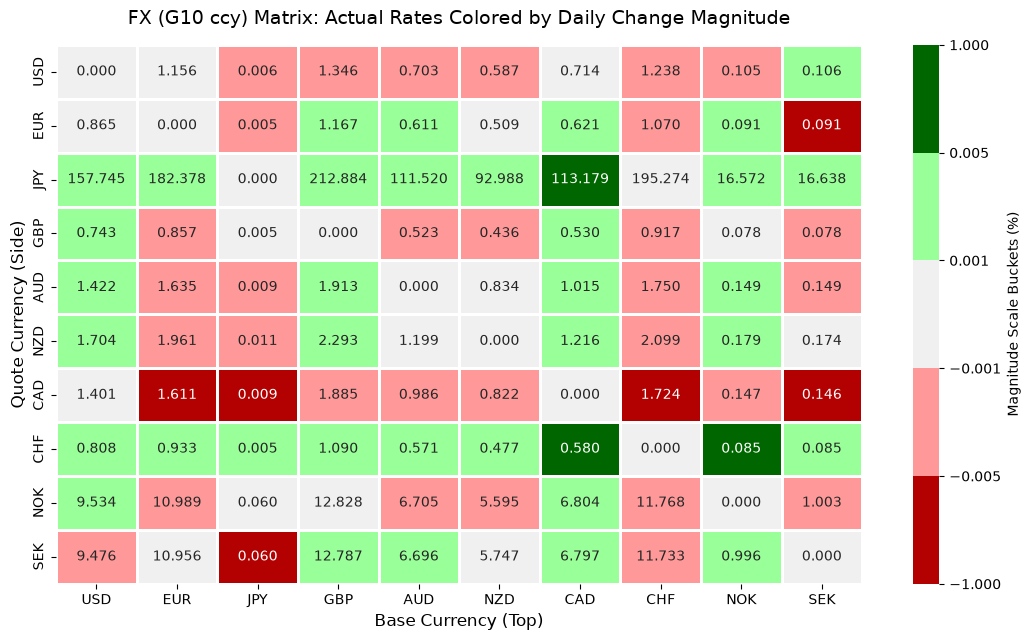

In [32]:
# lets put the heatmap matrix now. 

# 1. rotate the graph. 
heatmap_color_data = rate_change_matrix_df
heatmap_text_data = rate_matrix_df

# 2. create the custom magnitude color buckets
# colors: [Dark Red, Light red, Neutral/White, Light Green, Dark Green]
colors = ['#b30000', '#ff9999', '#f0f0f0', '#99ff99', '#006600']
custom_cmap = mcolors.ListedColormap(colors)

# Define boundaries based on criteria (-0.5%, -0.05%, 0.05%, 0.5%)
bounds = [-1, -0.005, -0.0005, 0.0005, 0.005, 1]
custom_norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

plt.figure(figsize=(13,7))

# plot the heatmap
sns.heatmap(
    heatmap_color_data,
    annot = heatmap_text_data, # Show the percentage values in the cells. 
    fmt = ".3f",   # Format numbers to 2 decimal places
    cmap = custom_cmap,   # Use custom discrete colors
    norm = custom_norm,   # Enforces the magnitude color rules
    cbar_kws = {'label' : 'Magnitude Scale Buckets (%)'},   
    linewidths = 1.0,   # Add thin lines between cells for readability.
    
)

plt.title("FX (G10 ccy) Matrix: Actual Rates Colored by Daily Change Magnitude", fontsize = 14, pad = 15)
plt.xlabel("Base Currency (Top)", fontsize = 12)
plt.ylabel("Quote Currency (Side)", fontsize = 12)
plt.show()

,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,0.000000,0.000405,-0.000919,-0.001063,-0.003387,-0.003263,-0.000250,-0.001238,-0.001164,0.000507
EUR,-0.000405,0.000000,-0.000820,0.001373,0.001146,0.000236,0.004679,-0.002157,0.001355,-0.005207
JPY,0.000920,0.001301,0.000000,0.002855,0.002697,0.002317,0.006027,-0.000456,0.002523,0.001246
GBP,0.001064,-0.001538,0.000213,0.000000,-0.001909,-0.002197,0.000774,-0.003706,-0.000077,-0.004217
AUD,0.003398,-0.001667,-0.001115,0.002321,0.000000,0.000108,0.003055,-0.003300,0.002195,-0.001439
NZD,0.003273,-0.001060,-0.001672,0.002220,-0.000150,0.000000,0.002961,-0.002788,0.002105,0.000000
CAD,0.000250,-0.005158,-0.006303,-0.000694,-0.003055,-0.002960,0.000000,-0.007130,-0.000889,-0.011483
CHF,0.001240,0.001298,0.001954,0.003028,0.003672,0.003749,0.006774,0.000000,0.005966,0.003622
NOK,0.001166,-0.001504,-0.000282,0.000480,-0.002190,-0.002101,0.000890,-0.002946,0.000000,-0.001470
SEK,-0.000506,-0.000057,-0.006254,0.001480,0.000842,0.000000,0.004463,-0.001550,0.000513,0.000000


,USD,EUR,JPY,GBP,AUD,NZD,CAD,CHF,NOK,SEK
USD,0.000000,1.156203,0.006339,1.345533,0.703340,0.586830,0.713587,1.238129,0.104892,0.105535
EUR,0.864900,0.000000,0.005483,1.166800,0.611300,0.509400,0.620500,1.070200,0.090930,0.090750
JPY,157.744995,182.378006,0.000000,212.884003,111.519997,92.987999,113.179001,195.274002,16.571600,16.638000
GBP,0.743200,0.856670,0.004692,0.000000,0.522700,0.436010,0.530330,0.916800,0.077909,0.077930
AUD,1.421787,1.634830,0.008962,1.912880,0.000000,0.834090,1.014530,1.750500,0.149132,0.149180
NZD,1.704070,1.960730,0.010751,2.292860,1.198550,0.000000,1.215960,2.099400,0.178743,0.174000
CAD,1.401370,1.610580,0.008829,1.885390,0.985530,0.822159,0.000000,1.724000,0.146982,0.146000
CHF,0.807670,0.933460,0.005127,1.089690,0.571310,0.476600,0.579670,0.000000,0.085154,0.085355
NOK,9.533650,10.988820,0.060220,12.827838,6.705481,5.594636,6.803556,11.768000,0.000000,1.002500
SEK,9.475520,10.956060,0.059590,12.786700,6.696100,5.747127,6.797000,11.732900,0.995500,0.000000


annot_matrix is: [['0.0000' '1.1562' '0.0063' '1.3455' '0.7033' '0.5868' '0.7136' '1.2381'
  '0.1049' '0.1055']
 ['0.8649' '0.0000' '0.0055' '1.1668' '0.6113' '0.5094' '0.6205' '1.0702'
  '0.0909' '0.0908']
 ['157.7450' '182.3780' '0.0000' '212.8840' '111.5200' '92.9880'
  '113.1790' '195.2740' '16.5716' '16.6380']
 ['0.7432' '0.8567' '0.0047' '0.0000' '0.5227' '0.4360' '0.5303' '0.9168'
  '0.0779' '0.0779']
 ['1.4218' '1.6348' '0.0090' '1.9129' '0.0000' '0.8341' '1.0145' '1.7505'
  '0.1491' '0.1492']
 ['1.7041' '1.9607' '0.0108' '2.2929' '1.1985' '0.0000' '1.2160' '2.0994'
  '0.1787' '0.1740']
 ['1.4014' '1.6106' '0.0088' '1.8854' '0.9855' '0.8222' '0.0000' '1.7240'
  '0.1470' '0.1460']
 ['0.8077' '0.9335' '0.0051' '1.0897' '0.5713' '0.4766' '0.5797' '0.0000'
  '0.0852' '0.0854']
 ['9.5337' '10.9888' '0.0602' '12.8278' '6.7055' '5.5946' '6.8036'
  '11.7680' '0.0000' '1.0025']
 ['9.4755' '10.9561' '0.0596' '12.7867' '6.6961' '5.7471' '6.7970'
  '11.7329' '0.9955' '0.0000']]
if you are 

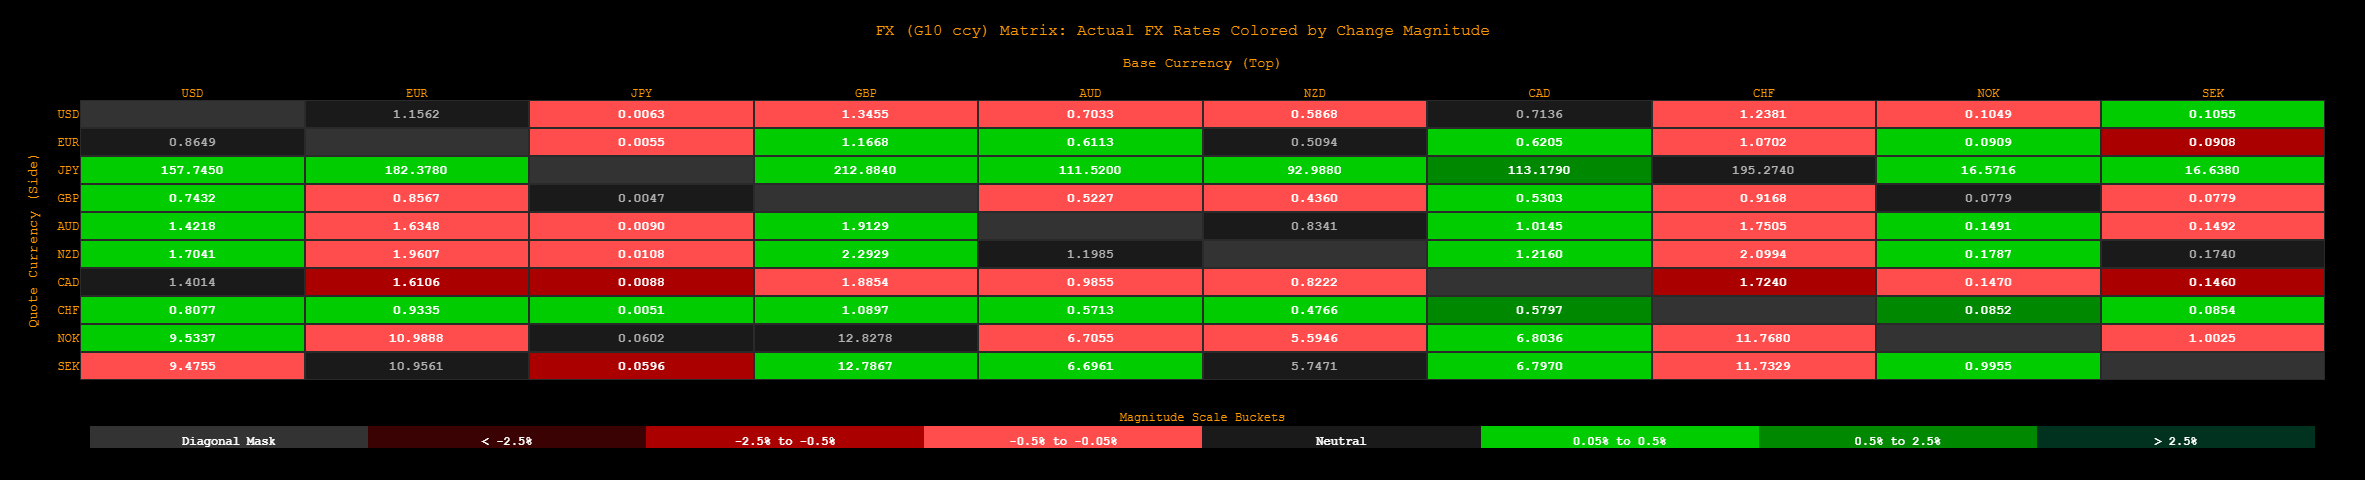

plotly graph should appear above!


In [33]:
# lets compare and use plotly. I feel like this would create a better and more friendly interface. 

# 1. set the same data 
# We have heatmap_color_data as the pct change of the rates on a daily basis.
# we also have the actual fx rates --> heatmap_text_data

display(heatmap_color_data)
display(heatmap_text_data)

# formatted currency text matrix for displace. 
annot_matrix = heatmap_text_data.map(lambda x : f"{x:.4f}").values
print(f"annot_matrix is: {annot_matrix}") # why?

# define discrete color buckets mapping to the scale
# bounds: [-1.0, -0.005, -0.001, 0.001, 0.005, 1.0]
# Plotly expects a colorscale mapped from 0 to 1, normalized evenly:
discrete_colorscale = [
    [0.000, '#333333'], [0.125, '#333333'],    # Masked Diagonal (0.0 to 0.125) 
    [0.125, '#3a0202'], [0.250, '#3a0202'],    # Bloomberg Deep Red 
    [0.250, '#aa0000'], [0.375, '#aa0000'],    # Bloomberg Red
    [0.375, '#ff4d4d'], [0.500, '#ff4d4d'],    # Bloomeberg Bright Red
    [0.500, '#1a1a1a'], [0.625, '#1a1a1a'],    # Dark Charcoal Neutral
    [0.625, '#00cc00'], [0.750, '#00cc00'],    # Soft Bright Green
    [0.750, '#008800'], [0.875, '#008800'],    # Mid Green
    [0.875, '#013220'], [1.000, '#013220'],    # Bloomberg Forest Green
]
print(f"if you are seeing this then we have ran through code blocks 1 till 1.")
# 2. Map color data values directly into uniform numeric bins [-1 to 1]
# this ensures Plotly breaks up the discrete color steps cleanly.
def digitize_values(val):
    if val <= -0.025:    return 1 # Deep Red
    if val <= -0.005:    return 2 # Red 
    if val <= -0.0005:   return 3 # Bright Red
    if val < 0.0005:     return 4 # Charcoal Neutral
    if val <= 0.005:     return 5 # Bright Neon Green
    if val <= 0.025:     return 6 # Green
    else:                return 7 # Forest green

color_bins = heatmap_color_data.map(digitize_values).values.copy() # add copy() at the end to make the array writable!
print(f"color_bins is: {color_bins}")

# 2.5: Map color bins and force diagonal to hit index 0 (Grey Mask block)
for i, row in enumerate(heatmap_color_data.index):
    for j, col in enumerate(heatmap_color_data.columns):
        if row == col:
            color_bins[i][j] = 0

# 3. built the plotly matrix
print(f"if you are seeing this then we have ran through code blocks 1 till 2.")
fig = go.Figure( data = go.Heatmap(
    z = color_bins,
    x = heatmap_color_data.columns,
    y = heatmap_color_data.index,
    colorscale = discrete_colorscale,
    showscale = True,
    zmin = -0.5,
    zmax = 7.5, # make sure this is 7.5 so it catches the 0.0 mask coordinates
    xgap = 2, # Added horizontal separation gap
    ygap = 2, # added vertical separation gap
    # Interactive custom hover template. 
    hovertemplate = "Base Ccy: %{x}<br>Quote Ccy: %{y}<br>Rate: %{text}<extra></extra>",
    text = annot_matrix,
    colorbar = dict(
        orientation = "h", # Flips the scale horizontally
        y = -0.28, # positions it cleanly below the matrix x-axis labels
        x = 0.5, # centers it horizontally
        xanchor = "center", 
        thickness = 22, # sets block height to fit text comfortably
        len = 1.0, # matches the full width of the matrix grid
        title = dict(text  = "Magnitude Scale Buckets", font = dict(color = "#ff9900", size = 12, family = "Courier New"), 
                     side = "top"), # Amber Color Font Title
        showticklabels = True,
        tickvals = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
        ticktext = [
            "Diagonal Mask",
            "< -2.5%", 
            "-2.5% to -0.5%", 
            "-0.5% to -0.05%", 
            "Neutral", 
            "0.05% to 0.5%", 
            "0.5% to 2.5%", 
            "> 2.5%"
        ],
        tickfont = dict(
            color = "white",
        size = 12,
        family = "Courier New",
        weight = "bold"), # Amber colorbar labels
        ticklabelposition = "inside" # injects the text directly inside the color bar rectangles                 
    )
))
print(f"if you are seeing this then we have ran through code blocks 1 till 3.")


# 4. superimpose actual fx rates text inside cells 
for i, row in enumerate(heatmap_color_data.index):
    for j, col in enumerate(heatmap_color_data.columns):
        #print(f"i is {i}, and row is: {row}")
        #print(f"j is {j}, and col is: {col}")
        cell_bin = color_bins[i][j]
        #print(f"cell_bin now is: {cell_bin}")
        # Pure Black text on bright neon cells, bright white text on deep/ neutral cells
        if row == col:
            display_text = "" # completely blank out diagonal text
            text_color = "rgba(0,0,0,0)"
        else:
            display_text = annot_matrix[i][j]
            # neutral cells look best with slightly muted gray to maintain hierarchy 
            # while all active colored cells get pure crisp white text
            text_color = "#b0b0b0" if cell_bin == 4 else "white"
            # 4 is Neutral
#            if cell_bin == 4:
#                text_color = "#b0b0b0"
#            # 3 is bright Red, 5 is Bright Neon Green
#            elif cell_bin in [3,5]:
#                text_color = "black"
#            # Dark outer colors
#            else:
#                text_color = "white"

        fig.add_annotation(
            x = col, 
            y = row,
            text = display_text,
            showarrow = False,

            font = dict(
                size = 13, 
                color = text_color,
                family = "Courier New, monospace", # Terminal style font
                weight = "bold"
            )
        )


# 4.5. Create a dict for the preset currencies as the title for the graph plot.
graph_title_dict = {"g10_ccy_list" : "FX (G10 ccy) Matrix: Actual FX Rates Colored by Change Magnitude",
                   'emea_ccy_list' : "FX (EMEA ccy) Matrix: Actual FX Rates Colored by Change Magnitude",
                   'asian_ccy_list' : "FX (Asian ccy) Matrix: Actual FX Rates Colored by Change Magnitude",
                   'latam_ccy_list' : "FX (LatAm ccy) Matrix: Actual FX Rates Colored by Change Magnitude",
                  }

print(f"if you are seeing this then we have ran through code blocks 1 till 4.")
# 5. clean layout styling for dark theme
fig.update_layout(
    title = dict(
        text = graph_title_dict[target_ccy_set],
        x = 0.5,
        y = 0.95,
        font = dict(size=16, color = "#ff9900", family = "Courier New")
    ),
    xaxis = dict(
        title = dict(text = "Base Currency (Top)", font=dict(color = "#ff9900", family = "Courier New")),
        side = "top", 
        tickangle = 0,
        tickfont = dict(color = "#ff9900", family = "Courier New"),
        showgrid = False # This removes the vertical lines inside the cells
        ),
    yaxis = dict(
        title = dict(text = "Quote Currency (Side)", font=dict(color = "#ff9900", family = "Courier New")),
        autorange = "reversed",
        tickfont = dict(color = "#ff9900", family = "Courier New"),
        showgrid = False # This removes the horizontal lines inside the cells.
    ),
    width = 1150, # Stretched from 900 to 1150 to widen the box 
    height = 480, # slightly taller to balance proportions.
    margin = dict(t = 100, b = 100, r = 40),
    paper_bgcolor = "#000000", # Pure Terminal Black/ outer margins remain pitch black
    plot_bgcolor = "#2a2a2a",  # Grid lines between cells turn into dark gray borders
)
print(f"if you are seeing this then we have ran through the entire code block and it is showing the figure below.")
fig.show()
print(f"plotly graph should appear above!")